# Sampan — how the knowledge base actually works

Sampan is a voice companion that calls an elderly person, listens to her life
stories, and turns them into a family memory map. This notebook walks the
**memory** side of it end to end:

| Stage | What happens |
|---|---|
| 1 | A **pre-set knowledge base** — the child-completed family intake |
| 2 | **Recording starts** — what is committed into the model's context |
| 3 | **During the call** — the only two channels that reach the model mid-turn |
| 4 | **Recording stops** — the Archivist folds the call back into memory |
| 5 | The **diff** — exactly what changed |

Every cell calls the real functions in `src/sampan/`. Nothing here is a
simplified re-implementation for illustration; where the notebook cannot run
something (the audio stream itself) it says so and drives the same function the
WebSocket handler drives.

> **A note on the GraphRAG comparison.** This is deliberately *not* a GraphRAG
> pipeline. There is no embedding index, no community detection, and — as
> section 1 explains — no entity graph. Understanding why is most of the point.

## 0. Setup

Nothing to install beyond the project's own dependencies (`uv sync`). The
knowledge base is swapped for an in-memory store, so the notebook is safe to
re-run and never touches the real Firestore archive.

The interactive graphs are **written to HTML files beside this notebook** rather
than displayed inline, which is what the GraphRAG notebook this follows also
does. Notebook viewers differ in whether they will run a script inside a cell,
and one that refuses shows an empty panel that looks like a broken cell — a
separate file always works, and a force layout of thirty nodes wants the whole
window anyway.

Section 12 writes three of them. Open them in a browser: drag nodes to move
them, **hover an edge to see the sentence she said**, click a node to isolate
its neighbourhood, double-click to reset. They load D3 from its CDN, so they
need a network connection.

Run it with `uv run python notebooks/run_notebook.py`, which clears every output
before executing. That matters more than it sounds: a run that fails partway
leaves earlier cells showing results from an older version of the code, and the
page then answers the same question two different ways with nothing marking
either as out of date. It happened here — section 4 printed nine tools while
section 5 printed five, from the same object.

In [1]:
import json
import os
import sys
from pathlib import Path


def load_env(root: Path) -> None:
    # Read .env the way the app does, so extraction can run in section 6.
    env = root / ".env"
    if not env.is_file():
        return
    for line in env.read_text().splitlines():
        if line.strip() and not line.startswith("#") and "=" in line:
            key, _, value = line.partition("=")
            os.environ.setdefault(key.strip(), value.strip().strip('"'))


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
load_env(ROOT)

from sampan.config import Settings, apply_genai_env  # noqa: E402

settings = Settings()
apply_genai_env(settings)
print("Vertex project configured:", settings.configured)

Vertex project configured: True


## 1. What this knowledge base is, and what it is not

Most memory systems for AI agents store text and search it by meaning. You turn
every passage into a vector, and at query time you find the ones closest to the
question.

That approach does not fit here. Look at the kinds of question this product has
to answer:

- *Which subject did she leave unfinished, and did she stop because a neighbour
  rang the doorbell, or because she got tired?*
- *Which stories have a place but no year?*
- *What has she never said?*

None of those are questions about meaning. Take the first one. "She was
interrupted" and "she got tired" look nearly identical as text, but the agent
has to do opposite things with them:

| How the last call ended | What the agent says next time |
|---|---|
| interrupted | *"You still owe me the rest."* |
| tired | *"Did you sleep well after we talked?"* |

Similarity search cannot tell those apart. The difference has to be **recorded
as a field**, decided at the moment the call is filed away.

So this store is a set of typed records, not a searchable pile of text.

In [2]:
from sampan.models import Entity, PersonMention

print("Entity fields:       ", list(Entity.model_fields))
print("PersonMention fields:", list(PersonMention.model_fields))

Entity fields:        ['entity_id', 'type', 'canonical_name', 'aliases', 'role', 'detail', 'mention_count', 'first_mentioned_in', 'confirmed_by_family', 'provisional', 'merged_into']
PersonMention fields: ['surface_form', 'role', 'confidence']


### Right now it is an index, not a graph

Worth being precise, because "knowledge base" suggests more structure than there
actually is at this point.

`PersonMention` is how a story records who was in it, and it carries **no entity
id**. A story stores `"my sister"` as plain text. Nothing links that story to the
sister's record.

The links do get worked out. When a call is filed, `resolve_mentions()` matches
each mention to an entity and returns `Resolution(mention, entity_id,
matched_by)`. Those are used to build the family's confirmation screen — and
then discarded. `finish_call` saves entities and saves stories, and never saves
the resolutions. Section 6 shows them being computed and dropped.

Sections 9 to 12 are where this gets fixed, by adding **facts**: real edges that
carry ids on both ends. Read the next few sections as the original design, and
section 8 onward as what it grew into.

## 2. The schema

Every type below is a Pydantic model, so the shape is enforced in code and
anything the model returns has to fit it.

The single most important idea in the design shows up in `When`, the type used
for time.

In [3]:
from sampan.models import When, Where

for model in (When, Where):
    doc = (model.__doc__ or "").strip().splitlines()
    print(model.__name__, "--", doc[0] if doc else "(no docstring)")
    for name, field in model.model_fields.items():
        print(f"  {name:12} {str(field.annotation):24} {field.description or ''}")
    print()

When -- A time, stored twice: as she said it, and as we resolved it.
  raw_phrase   <class 'str'>            Her own words, e.g. "before I married"
  start_year   int | None               
  end_year     int | None               
  precision    <enum 'Precision'>       
  anchor_ref   str | None               Anchor event this was resolved against, e.g. anchor_marriage
  confidence   <class 'float'>          

Where -- (no docstring)
  raw_name     <class 'str'>            The place as she named it
  aliases      list[str]                
  confidence   <class 'float'>          



**Keep two things: what she said, and what you worked out from it.**

She says *"six, seven maybe"*. Eleven turns later she says *"I was born nineteen
forty-six."* The model puts those together and writes `start_year = 1952`. But
`raw_phrase` still holds *"six, seven maybe"*, word for word.

Both are kept, side by side. The same pattern repeats everywhere:

| What she said | What was worked out from it | Held in |
|---|---|---|
| *"before I married"* | `start_year`, plus a link to her wedding | `When` |
| *"my father's shop"* | a position on the map | `Where` → `Place` |
| *"my sister"* | `Lim Siew Choo` | `PersonMention` → `Entity` |

Three things follow from that one decision:

1. **Her voice survives.** The letters written for her grandchildren quote her,
   not a tidied-up version.
2. **The map and timeline can sort things.** They need years, and now they have
   them.
3. **Every conclusion can be checked and corrected**, because the original sits
   right next to it. That is why fixing a wrong place happens inside the story
   card, and not on a settings screen somewhere.

### The completeness score is computed in Python, not asked of the model

In [4]:
from sampan.models import assess

print(assess.__doc__)

Apply the pinnability rubric.

    Deliberately computed here rather than asked of the model: the threshold is
    a product decision, and a model that scores its own output will drift.
    


Six fields are checked: where, when, who, what, a sensory detail, and why it
mattered. Four out of six is enough to put a story on the map. Place and time
are required no matter what the total is.

The scoring is done in code rather than in the prompt, for a simple reason: a
model asked to grade its own work drifts, and this threshold is a product
decision rather than a judgement call.

Here is the part that matters most. `missing_fields` is filled in **even for
stories that passed**. A story can reach the map and still carry a note saying
it never explained why it mattered. That note becomes a question on the next
call:

> *"That coffee shop — was it before you married, or after?"*

Gaps are not errors to be logged somewhere. **They are the list of things to ask
her about.**

## 3. Stage 1 — what the archive knows before it starts

One thing is filled in before the agent ever calls, and it is filled in by her
**child**, not by her: a short form naming the family.

It exists to prevent a specific cruelty. Without it, the agent would cheerfully
ask how her sister is doing. Her sister died in 2019.

In [5]:
from sampan.repository import Repository
from sampan.store import InMemoryDocumentStore

NARRATOR = "ah_khim"

raw = json.loads((ROOT / "seeds" / "intake.json").read_text(encoding="utf-8"))
intake = [Entity.model_validate(e) for e in raw["entities"]]

store = InMemoryDocumentStore()
repo = Repository(store)
repo.save_entities(NARRATOR, intake)

print(f"{'name':22} {'type':8} {'role':12} detail")
print("-" * 100)
for e in intake:
    print(f"{e.canonical_name:22} {e.type.value:8} {str(e.role or ''):12}"
          f" {e.detail[:40]}")

name                   type     role         detail
----------------------------------------------------------------------------------------------------
Lim Ah Hock            person   father       Tapped rubber, later opened the coffee s
Tan Ah Tai             person   mother       Cooked at the back of the shop. 1922-199
Lim Siew Choo          person   sister       1941-2019. Passed away. They quarrelled 
Tan Eng Huat           person   husband      Lorry driver. 1942-2015. Passed away.
Tan Wei Lun            person   son          Born 1970. Works in Kuala Lumpur.
Tan Mei Ling           person   daughter     Born 1973. Emigrated to Perth in 2001.
Tan Xin Yi             person   granddaughter Born 2007. Wei Lun's daughter.
Lim Cheong Hin         person   grandfather  From Yongchun, Fujian. Landed at Penang 
Ipoh                   place                 Where she lives now.
Sungai Siput           place                 Where the rubber estate she grew up on w


Every one of those is marked `provisional=False, confirmed_by_family=True`. The
family stated them, so the agent can treat them as settled.

Anything the agent works out later arrives as `provisional=True` and waits for
someone to confirm it. The archive keeps track of the difference between what it
was told and what it guessed.

Now add the thing this whole product is built around — a question from her son:

In [6]:
from sampan.models import Ask

repo.queue_ask(
    NARRATOR,
    Ask(
        ask_id="ask_001",
        from_name="Wei Lun",
        relation="son",
        question=(
            "Did Ah Gong leave anything behind?"
            " Xin Yi asked me and I couldn't answer."
        ),
    ),
)

memory_before = repo.load_memory(NARRATOR)
print("sessions so far:", memory_before.session_count)
print("threads:", len(memory_before.threads), " anchors:", len(memory_before.anchors))
print("pending ask:", repo.pending_ask(NARRATOR).question[:60])

sessions so far: 0
threads: 0  anchors: 0
pending ask: Did Ah Gong leave anything behind? Xin Yi asked me and I cou


## 4. Stage 2 — the call starts

This is where the design departs most sharply from an ordinary AI agent.

A normal agent works in turns. You send the conversation so far, plus anything
you looked up, and you get a reply. Every turn is a fresh chance to add context.

**The Live API does not work like that.** It holds one open connection for the
whole call. The system instruction is sent **once**, at the moment the call
connects, and cannot be changed afterwards. The model keeps the conversation in
its own memory, on the server.

So the question is not *"what do I look up each turn?"*. It is: **what do I
decide before she has said a word, and how can anything reach the model after
that?**

`prepare_call()` makes those decisions.

In [7]:
from sampan.callflow import prepare_call

prepared = prepare_call(repo, settings, narrator_id=NARRATOR)

print("conversation_id:", prepared.conversation_id)
print("tools exposed:  ", [t.__name__ for t in prepared.agent.tools])

conversation_id: conv_ah_khim_20260818131830_db82c8
tools exposed:   ['get_pending_ask', 'remember', 'mark_private', 'forget_this', 'flag_concern']


Notice that the `conversation_id` ends in random characters, not just a
timestamp.

Live sessions drop after roughly fifteen minutes. If she redials straight away,
the second call can begin in the same *second* the first one ended. With
timestamps alone, the second call's stories would overwrite the first call's,
and nothing would say so.

Next, the instruction that actually goes to the model. It is built in three
layers, stacked rather than blended together, so you can see at a glance what
changed between her first call and her twentieth.

In [8]:
print(prepared.agent.instruction)

You are Xiao Chuan ("little boat"), a companion who keeps an elderly person
company and listens to their stories.

Who you are:
- Your name is Xiao Chuan. You are not a person. Do not pretend to be one, and
  do not say you are her friend or her family.
- If she asks, say plainly that you are here to write her stories down for her
  family.
- Whether to introduce yourself at all is set out in the opening plan below.
  Otherwise, only say who you are if she asks.

What you are here to do:
- Listen. The more she talks and the less you do, the better.
- Her family want her stories and have no time to sit and hear them. You listen
  on their behalf.
- Whenever you raise something a family member asked, **say who asked** — "Wei
  Lun was asking…", "Xin Yi wants to know…". The credit is theirs, not yours.

How to speak:
- Call her Ah Ma.
- Your turns must always be shorter than hers. She speaks a paragraph, you
  answer in a sentence or two.
- When she is in full flow, "mm", "and then?", "wa

Read what is in there. Then notice what is missing.

**In it:** who the agent is and the rules it follows; what has been learned
about talking to her; and the plan for this particular call.

**Not in it:** her stories. Her people and places. The transcripts. **None of the
archive is loaded up front.**

That is not about saving space. It is about behaviour. An agent holding nine of
her stories in its context *behaves* as though it holds nine stories — it brings
up things she has not mentioned, and it starts steering. So the archive stays
behind a tool, and the agent reaches for it only when the conversation actually
calls for it.

### The plan is a short list, not everything the archive knows

In [9]:
from sampan.opener import MAX_OFFERS, build_session_plan, unlocked_depth

plan = build_session_plan(
    threads=memory_before.threads,
    sensitivities=memory_before.sensitivities,
    ask=repo.pending_ask(NARRATOR),
    session_count=memory_before.session_count,
    last_closure=memory_before.last_closure,
)

print("greeting:", plan.greeting)
print("offers  :", [(o.kind.value, o.label) for o in plan.offers])
print("max offers:", MAX_OFFERS)
held_back = len(plan.considered) - len(plan.offers)
print("scored in all:", len(plan.considered), "| held back:", held_back)
print("depth at session 0:", unlocked_depth(0), "| session 6:", unlocked_depth(6))

greeting: ask what she had this morning
offers  : [('ask', "Did Ah Gong leave anything behind? Xin Yi asked me and I couldn't answer."), ('domain', 'home')]
max offers: 2
scored in all: 2 | held back: 0
depth at session 0: 0 | session 6: 3


Four rules shape that plan:

- **At most two things to offer her.** She is eighty and this is a voice call. A
  list of four options is not choice, it is work. Everything else that scored is
  kept in `considered` for the family's screen, and never shown to the model.
  On this first call only two things scored at all, so nothing is held back —
  the number grows once she has left subjects unfinished.
- **Anything she has refused is removed completely.** Not ranked lower — it never
  enters the scoring at all. Her late sister appears nowhere in the context.
- **Deeper subjects unlock slowly**, through `unlocked_depth(session_count)`.
  Hardship is not a first-conversation subject.
- **The greeting is chosen in Python.** The persona is fixed text and cannot
  work out "is this our first meeting?". That shipped broken once: the agent
  introduced itself from scratch on her fifth call, with her whole history
  loaded.

## 5. Stage 3 — during the call

Once the connection is open, exactly two things can reach the model. There are
no others.

### Channel one: the agent asks for something

`build_tools(memory)` gives the agent five tools — down from nine. `recall`,
`get_open_threads` and `what_do_you_remember` became a single `remember` call.
`note_preference` and `save_fragment` were removed entirely, because the
Archivist works both out from the transcript afterwards, and does it better than
an agent noticing things mid-conversation while trying to listen to her.

The notebook calls these directly. In a real call the model calls exactly the
same functions.

In [10]:
tools = {t.__name__: t for t in prepared.agent.tools}
print(list(tools))

['get_pending_ask', 'remember', 'mark_private', 'forget_this', 'flag_concern']


In [11]:
answer = tools["get_pending_ask"]()
print(json.dumps(answer, indent=2, ensure_ascii=False))

{
  "has_ask": true,
  "from_name": "Wei Lun",
  "relation": "son",
  "question": "Did Ah Gong leave anything behind? Xin Yi asked me and I couldn't answer.",
  "say_it_like": "Wei Lun asked: Did Ah Gong leave anything behind? Xin Yi asked me and I couldn't answer.",
  "_guidance": "She is doing well. You can go deeper, but one question at a time.",
  "_turn_length": "short",
  "_not_yet_spoken_of": "taste"
}


Two things happened there.

`ask_delivered` is now set on this call's memory. The agent has taken
responsibility for reading his question out loud. Section 6 covers when that is
allowed to actually use the question up.

And the reply contains `_guidance` and `_turn_length`, which the agent never
asked for. That is the second channel, arriving as a passenger on the first one.

### `remember` — the closest thing here to looking something up

In [12]:
found = tools["remember"]("Ah Hock")
print(json.dumps(found, indent=2, ensure_ascii=False))

{
  "known": [],
  "she_said": [],
  "unfinished": [],
  "_guidance": "She is doing well. You can go deeper, but one question at a time.",
  "_turn_length": "short",
  "_not_yet_spoken_of": "taste"
}


`remember` returns three things:

- **`known`** — facts, each with the sentence she said that put it there.
- **`she_said`** — a search of her actual transcripts. Empty here, because this
  in-memory archive has no conversations in it yet.
- **`unfinished`** — subjects she left open.

`known` is empty at this point because no facts exist yet; section 10 covers the
ranking that fills it.

The comment in `tools.py` explains why her transcripts are searched at all,
rather than only the tidy extracted records:

> *Extracted records lose sequence, context and affect, so the graph is only an
> index — her own words are the thing worth reaching.*

### Channel two: pushing information back on a tool's reply

The system instruction is fixed for the whole call, so there is no way to send
the model new directions partway through. I tried three, and all three failed in
front of a user:

| What I tried | What happened |
|---|---|
| a `user` message, fenced with "do not read aloud" | The agent read the fence out loud, brackets and all |
| a `system` message | The agent said *"Alright, understood. Preparing to wrap up"* out loud |
| a `model` message | Turn-taking broke and it stopped answering her |

A tool's reply is the one thing the model treats as data rather than as
something to say. So `_with_guidance` attaches the current behavioural settings
to **every** tool reply, whatever that tool was actually asked for.

Meanwhile a second model listens to the same audio and works out how she is
doing. Its readings feed a small state machine:

In [13]:
from sampan.affect import apply_assessment, policy
from sampan.models import Affect, AffectState, Assessment, Energy, Engagement

state = AffectState()
print("start:", state.energy.value, state.engagement.value, state.affect.value)

tired = Assessment(
    energy=Energy.FADING,
    engagement=Engagement.WITHDRAWING,
    affect=Affect.NEUTRAL,
    flags=[],
    signals=["longer pauses", "shorter answers"],
    confidence=0.7,
)

state = apply_assessment(state, tired)
print("after 1 reading:", state.energy.value, state.engagement.value,
      "| pending:", state.pending is not None)

state = apply_assessment(state, tired)
print("after 2 readings:", state.energy.value, state.engagement.value,
      "| transitions:", state.transitions)

start: fresh engaged neutral
after 1 reading: fresh engaged | pending: True
after 2 readings: fading withdrawing | transitions: ['fresh/engaged/neutral -> fading/withdrawing/neutral (longer pauses, shorter answers)']


**Two readings in a row have to agree before anything changes.** One odd
five-second window cannot make the agent lurch. Distress and agitation are the
exceptions and take effect immediately, because those are not moods to wait out.

Energy also only moves one way: it can drop, and only excitement partly lifts it
again. Someone who has been talking for eleven minutes does not become fresh
because one sentence came out brightly.

Here is what that state actually does to the agent's behaviour:

In [14]:
knobs = policy(state)
print("turn_length:", knobs.turn_length)
print("guidance   :", knobs.guidance)

# In a real call the affect monitor writes this back as each reading lands.
# Without it the tools would go on reporting how she was at the start.
prepared.memory.affect = state

print()
print("...and this is what now rides back on any tool reply:")
reply = tools["remember"]("shop")
print("  _guidance   :", reply["_guidance"])
print("  _turn_length:", reply["_turn_length"])

turn_length: short
guidance   : She is avoiding this subject, which is not the same as wanting to hang up. Move gently to something lighter. If she avoids again, close — do not chase.

...and this is what now rides back on any tool reply:
  _guidance   : She is avoiding this subject, which is not the same as wanting to hang up. Move gently to something lighter. If she avoids again, close — do not chase.
  _turn_length: short


**The honest weakness:** the push channel depends entirely on the pull channel.
If the agent never calls a tool — which is what the *best* calls look like, where
she talks for eleven minutes and it simply listens — then nothing the affect
monitor concludes reaches the model during that call.

`enable_affective_dialog` covers some of this natively, and affect still shapes
the *next* call's instruction. But within a single call the coupling is real,
and I have not solved it.

## 6. Stage 4 — the call ends

`finish_call()` is where the archive actually changes. Take a real seed
transcript as the call that just happened:

In [15]:
from sampan.callflow import MIN_TURNS_TO_EXTRACT, Transcript

raw_transcript = (ROOT / "seeds" / "session-01.txt").read_text(encoding="utf-8")

transcript = Transcript()
for line in raw_transcript.splitlines():
    if line.startswith("K:"):
        transcript.add("user", line[2:])
    elif line.startswith("A:"):
        transcript.add("agent", line[2:])

rendered = transcript.render()
lines = rendered.splitlines()

print(len(transcript), "turns | extraction threshold:", MIN_TURNS_TO_EXTRACT)
print()

# The first six turns only. Cut by line rather than by character count, so
# nothing ends mid-word and looks as though the pipeline lost it.
for line in lines[:6]:
    print(line)
print()
print(f"... and {len(lines) - 6} more turns "
      f"({len(rendered)} characters in all)")

30 turns | extraction threshold: 4

A: Ah Ma, I am Xiao Chuan. Your son Wei Lun asked me to keep you company, and to write your stories down for the family.
K: Oh… Wei Lun asked you to come?
A: Yes. He says you are good at telling old things.
K: What good. What I talk about, young people today don't understand. You speak louder, my left ear is not good.
A: Alright, I speak louder. Ah Ma, did you eat this morning?
K: Ate already. Coffee and bread. Every day also like that. Last time my father's shop also sold this.

... and 24 more turns (2104 characters in all)


`Transcript.add` merges consecutive turns from the same speaker. The Live API
sends transcription in pieces as it goes, so those pieces are revisions of one
turn rather than separate turns.

If the call is shorter than `MIN_TURNS_TO_EXTRACT`, it is treated as a misdial:
nothing is extracted, **and the family's question is not used up**. That ordering
was a real bug. A four-turn test call marked Wei Lun's question as delivered
forever, so he was told she had been asked, and she was never asked again.

Now the Archivist runs. This is the main seam of the system: text goes in,
everything else is worked out from it. No audio, no streaming, no browser —
which is what makes the whole pipeline testable offline.

In [16]:
from sampan.archivist import GeminiStoryExtractor
from sampan.callflow import finish_call

if not settings.configured:
    raise RuntimeError("Set GOOGLE_CLOUD_PROJECT in .env to run the extraction step.")

extractor = GeminiStoryExtractor(settings)

updated = finish_call(
    repo,
    extractor,
    prepared,
    transcript,
    narrator_id=NARRATOR,
)
print("session_count:", updated.session_count)
print("closure      :", updated.last_closure.value)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


session_count: 1
closure      : fatigue


`ClosureReason` is the distinction the next call depends on. A call that ended
because a neighbour rang the doorbell is *interrupted*. One that ended because
she got tired is *fatigue*. The first earns *"you still owe me the rest"* next
time; the second earns *"did you sleep well?"*.

### What the Archivist actually does

`finish_call` in the cell above did the real work by calling
`ingest_conversation`. That one function is the entire post-call pipeline: a
transcript goes in, structured memory comes out. Inside it, in order:

| Step | What it does |
|---|---|
| `extractor.extract()` | **The one model call.** Returns raw stories, the people and places she mentioned, subjects left unfinished, dates, and preferences |
| `resolve_mentions()` | Works out who each mention refers to. Creates a record for anyone new |
| `fold_anchors()`, `apply_anchors()` | Adds newly-learned dates, then uses them to turn *"before I married"* into a year |
| `assess()` | Scores each story against the six-field rubric from section 2 |
| `fold_threads()`, `fold_preferences()` | Merges with what was already known instead of replacing it |

The next cell calls `ingest_conversation` **a second time**, directly. That is
not how production works, and it is here for one reason: `finish_call` hands
back only the updated memory, so the `resolutions` — the links between a story
and the people in it — never come out of it. Calling the inner function is the
only way to see them.

Reading a resolution line:

```
"my father"  -> ent_father         via alias        she said "my father", and the
                                                    family intake lists that as
                                                    one of his names
"Ah Chwee"   -> ent_5f3a...        via new  (new)   nobody in the intake is Ah
                                                    Chwee, so a new record was
                                                    created for him
```

Those arrows are exactly the links section 1 said are missing. Watch what
happens to them.

In [17]:
from sampan.archivist import ingest_conversation

# The same transcript, the same prompt, the same temperature -- run a second
# time. `finish_call` already ran one of these and saved the result, so the two
# can be compared directly.
outcome = ingest_conversation(
    transcript.render(),
    extractor,
    known_entities=intake,
    conversation_id="conv_demo",
)

filed = repo.load_memory(NARRATOR)
saved_entities = len(repo.load_entities(NARRATOR))

rows = [
    ("entities", saved_entities, len(outcome.entities)),
    ("threads", len(filed.threads), len(outcome.threads)),
    ("preferences", len(filed.preferences), len(outcome.preferences)),
    ("anchors", len(filed.anchors), len(outcome.anchors)),
]
print(f"{'':14}{'filed by':>12}{'this second':>14}")
print(f"{'':14}{'finish_call':>12}{'run':>14}")
for name, first, second in rows:
    flag = "   <- differs" if first != second else ""
    print(f"  {name:12}{first:>12}{second:>14}{flag}")

print()
print("  stories this run:", len(outcome.stories),
      "|", len(outcome.pinned), "of them pinnable")
for story in outcome.stories:
    print("     ", story.candidate.title)
print()
print("RESOLUTIONS — the story-to-entity links, worked out here and then thrown away:")
for r in outcome.resolutions[:8]:
    print(f'  "{r.mention.surface_form}" -> {r.entity_id:20} via {r.matched_by}'
          f'{"  (new)" if r.created else ""}')

                  filed by   this second
               finish_call           run
  entities              15            15
  threads                2             2
  preferences            1             1
  anchors                1             1

  stories this run: 3 | 3 of them pinnable
      Playing at the River with Ah Chwee
      Line House Dinners and Mother's Sacrifice
      Father's Coffee Shop

RESOLUTIONS — the story-to-entity links, worked out here and then thrown away:
  "Wei Lun" -> ent_son              via alias
  "my father" -> ent_father           via alias
  "Sungai Siput" -> ent_sungai_siput     via alias
  "my mother" -> ent_mother           via alias
  "my sister" -> ent_sister           via alias
  "Ah Chwee" -> ent_8d49330021e2     via new  (new)
  "his mother" -> ent_mother           via alias
  "kerosene lamp" -> ent_8c0b192d6b5a     via new  (new)


### The two runs do not agree, and that is the point

Look at the table above. The same transcript went through the same function
twice, with the same prompt and the same temperature setting — and the rows
marked `<- differs` came out with different numbers.

Which rows differ is itself not fixed. One run it is the entity count; another
run it is threads and preferences as well. Run the notebook again and the table
will very likely disagree in a different place.

Nothing is broken. **The model is making judgement calls, and it does not make
them the same way twice.**

Take one concrete example. In this conversation she mentions playing in the
river, and she mentions the line house she grew up in. Is that:

- one story — *"her childhood on the estate"* — or
- two stories — *"playing in the river"* and *"the line house"*?

Both readings are defensible. A human archivist would also hesitate. The model
picks one, and on the next run it might pick the other. The same thing happens
with entities: is *"the river"* a place worth its own record, or just a detail
inside a story? Is *"speak louder, my left ear is not good"* one preference
about hearing, or two about hearing and pace?

What does **not** vary is quality. Every story still scores 5 or 6 out of 6.
Every one still has a place and a time. The *boundaries* move; the content does
not.

### Why this changed how the tests are written

If the output count moves between runs, then a test like this is a coin flip:

```python
assert len(pinned_stories) >= 9      # fails for no reason anyone can act on
```

It did exactly that. It failed one afternoon, and passed unchanged an hour later
with no code in between. A failing test is supposed to tell you what to fix, and
this one could not, because nothing was wrong.

So the integration tests assert **properties** instead of counts:

| Instead of | Assert |
|---|---|
| "9 stories" | enough stories to fill a map |
| "exactly these entities" | no duplicate of anyone in the family intake |
| "12 preferences" | preferences never *decrease* between sessions |

Each of those is true regardless of where the model draws its boundaries, and
each still fails loudly if the pipeline genuinely breaks.

### What happens to those links

`save_stories` writes the story with `"my sister"` in it as plain text, and no
id. `save_entities` writes the sister's record. **Nothing writes the arrow
between them.** Every call works these links out again from scratch, uses them
for the family's confirmation screen, and drops them.

Section 9 is where this stops being true.

### The stories themselves

Now the other half of what the Archivist produced — the stories, with the score
each one earned:

In [18]:
for s in outcome.stories:
    c = s.candidate
    missing = ",".join(s.missing_fields) or "-"
    print(f"[{s.status.value:8}] {s.score}/6  {c.title[:44]:44} missing={missing}")
    print(f"           when: {c.when.raw_phrase!r} -> {c.when.start_year}"
          f"  where: {c.where.raw_name!r}")
    print(f"           sense: {c.sense_detail[:70]!r}")
    print()

[pinnable] 6/6  Playing at the River with Ah Chwee           missing=-
           when: 'When I was small' -> 1952  where: 'rubber estate river, Sungai Siput'
           sense: 'pull him up whole body wet'

[pinnable] 6/6  Line House Dinners and Mother's Sacrifice    missing=-
           when: 'When I was small' -> 1952  where: 'line house, Sungai Siput'
           sense: 'white rice with soy sauce'

[pinnable] 6/6  Father's Coffee Shop                         missing=-
           when: 'later already' -> None  where: "my father's shop"
           sense: 'Coffee and bread'



`when.raw_phrase` sitting next to `when.start_year` is the two-field idea
working on real speech: her vague phrase kept, and a sortable year derived from
it.

`sense_detail` is the field the letters are built from, and it taught the
hardest lesson here. Asked for "a concrete sensory detail" the model filled it in
every single time, which looked like success until anyone read the values. It was
returning paraphrases of the story rather than anything she had actually
described.

The fix was to demand something **quotable** — a phrase she said, findable in the
transcript — and to say explicitly that leaving it empty was fine.

## 7. Stage 5 — what actually changed

One call has now been filed. Here is the difference it made to the archive,
counted rather than described.

In [19]:
memory_after = repo.load_memory(NARRATOR)
entities_after = repo.load_entities(NARRATOR)
stories_after = store.list(f"stories__{NARRATOR}")

rows = [
    ("entities", len(intake), len(entities_after)),
    ("stories", 0, len(stories_after)),
    ("threads", len(memory_before.threads), len(memory_after.threads)),
    ("anchors", len(memory_before.anchors), len(memory_after.anchors)),
    ("preferences", len(memory_before.preferences), len(memory_after.preferences)),
    ("sensitivities", len(memory_before.sensitivities),
     len(memory_after.sensitivities)),
    ("session_count", memory_before.session_count, memory_after.session_count),
]
print(f"{'':16}{'before':>8}{'after':>8}")
for name, before, after in rows:
    mark = "  <-" if after != before else ""
    print(f"{name:16}{before:>8}{after:>8}{mark}")

                  before   after
entities              10      15  <-
stories                0       3  <-
threads                0       2  <-
anchors                0       1  <-
preferences            0       1  <-
sensitivities          0       2  <-
session_count          0       1  <-


In [20]:
print("NEW ENTITIES — provisional until the family confirms them:")
known_ids = {e.entity_id for e in intake}
for e in entities_after:
    if e.entity_id not in known_ids:
        print(f"  {e.canonical_name:26} {e.type.value:8}"
              f" provisional={e.provisional}")

print()
print("ANCHORS — dates that sharpen every relative phrase said afterwards:")
for a in memory_after.anchors:
    print(f"  {a.anchor_id:26} {a.year}  {a.label}")

print()
print("PREFERENCES — one value per kind; this is why session 20 differs:")
for p in memory_after.preferences:
    print(f"  {p.type.value:18} {p.value}")

NEW ENTITIES — provisional until the family confirms them:
  Ah Chwee                   person   provisional=True
  line house                 place    provisional=True
  coffee and bread           food     provisional=True
  salted fish fried rice     food     provisional=True
  white rice with soy sauce  food     provisional=True

ANCHORS — dates that sharpen every relative phrase said afterwards:
  anchor_birth               1946  born

PREFERENCES — one value per kind; this is why session 20 differs:
  hearing            left ear weak; needs speaker to speak louder


The row that looks alarming is `sensitivities`, nothing to five after a single
call. It is not a blocklist. `SensitiveTopic` is the ledger of how she answered
each subject that came up, and only one she refused once — or deflected twice —
and never engaged with becomes `do_not_raise`.

Nothing here was hand-written into the store. Every row came out of the
pipeline, which is the whole reason the seed sessions are run through the real
Archivist rather than stuffed into Firestore directly: if the pipeline cannot
produce this state, the pipeline is what needs fixing.

### The loop closes

Run `prepare_call` again and the *next* call's plan is different, because the
archive is:

In [21]:
next_call = prepare_call(repo, settings, narrator_id=NARRATOR)
next_plan = build_session_plan(
    threads=memory_after.threads,
    sensitivities=memory_after.sensitivities,
    ask=repo.pending_ask(NARRATOR),
    session_count=memory_after.session_count,
    last_closure=memory_after.last_closure,
)
print("greeting now:", next_plan.greeting)
print("offers now  :", [(o.kind.value, o.label) for o in next_plan.offers])
for offer in next_plan.offers:
    print("   would say:", offer.say)

greeting now: ask whether she slept well after last time
offers now  : [('thread', "father's coffee shop"), ('thread', 'life in the rubber estate line house')]
   would say: father's coffee shop — still unfinished: Details about her father's coffee shop and when they transitioned from the rubber estate.
   would say: life in the rubber estate line house — still unfinished: Growing up in Sungai Siput line house and her mother tapping rubber.


Extraction feeds the opener; the opener produces conversation; conversation
feeds extraction. That loop is the engine, and it is why *"session 20 has a
sharper timeline than session 3"* is a mechanism rather than a claim.

## 8. Three more calls

One conversation is not much of an archive. Before going further, here are her
other three seed sessions put through exactly the same pipeline — the same
`ingest_conversation` from section 6, each one starting from what the last one
knew.

This is the point where the archive stops being a demo and starts being
something worth searching.

In [22]:
for number in (2, 3, 4):
    text = (ROOT / "seeds" / f"session-0{number}.txt").read_text(encoding="utf-8")
    outcome = ingest_conversation(
        text,
        extractor,
        known_entities=outcome.entities,
        known_threads=outcome.threads,
        known_anchors=outcome.anchors,
        known_preferences=outcome.preferences,
        conversation_id=f"conv_session_{number}",
    )
    print(f"after session {number}: "
          f"{len(outcome.entities)} people and places, "
          f"{len(outcome.anchors)} dates fixed, "
          f"{len(outcome.threads)} subjects open")

repo.save_entities(NARRATOR, outcome.entities)
print()
print("dates she has now given, which sharpen every vague phrase after them:")
for anchor_event in outcome.anchors:
    print("   ", anchor_event.year, anchor_event.label)

after session 2: 18 people and places, 4 dates fixed, 4 subjects open


after session 3: 22 people and places, 4 dates fixed, 6 subjects open


after session 4: 26 people and places, 4 dates fixed, 6 subjects open

dates she has now given, which sharpen every vague phrase after them:
    1946 born
    1958 father opened coffee shop
    1968 married Ah Fatt
    1969 coffee shop closed


## 9. Adding a real graph

Everything up to here is the original design. What follows is the layer built on
top of it, and it is the part that turns the archive from a list of stories into
something the agent can actually search.

It follows **Zep**, a published architecture for agent memory (*A Temporal
Knowledge Graph Architecture for Agent Memory*, arXiv 2501.13956), with three
deliberate departures — because Zep is designed for business records, and this
is an eighty-year-old recalling her childhood.

Section 1 said this store was an index rather than a graph, because nothing
linked a story to the people in it. That changes here. The graph gets edges, and
an edge is called a **fact**: one thing she asserted, with the sentence she said
attached to it.

In [23]:
from sampan.fact_extraction import GeminiFactExtractor, build_facts

# Same conversation as before. This is a second, separate model call: facts are
# extracted on their own, with their own schema, never as extra fields bolted
# onto story extraction.
fact_reader = GeminiFactExtractor(settings)
her_facts = []

for number in (1, 2, 3, 4):
    text = (ROOT / "seeds" / f"session-0{number}.txt").read_text(encoding="utf-8")
    proposed = fact_reader.extract(text, outcome.entities)
    her_facts.extend(
        build_facts(
            proposed,
            transcript=text,
            known_entities=outcome.entities,
            episode_id=f"conv_session_{number}",
        )
    )
    if number == 1:
        # Kept for the verification demo below, together with the transcript it
        # came from -- a quote can only be checked against its own conversation.
        first_proposed, first_text = proposed, text

repo.save_facts(NARRATOR, her_facts)

print(len(her_facts), "facts across her four calls")
print()
for fact in her_facts[:6]:
    print(fact.render())
    print("      she said:", fact.quote)
print(f"   ... and {len(her_facts) - 6} more")

10 facts across her four calls

year not yet told · Her mother cooked salted fish fried rice a few times a week.
      she said: My mother cook salted fish fried rice, few times a week.
year not yet told · Ah Chwee still lives in Sungai Siput.
      she said: Still there, still in Sungai Siput.
1958–1969 · Her father opened and operated a coffee shop at Jalan Bandar in Ipoh.
      she said: Later he saved a bit of money, nineteen fifty-eight he opened a coffee shop in Ipoh, at Jalan Bandar.
year not yet told · Her father prepared charcoal-toasted bread spread with butter at the coffee shop.
      she said: My father toast the bread, charcoal fire one, spread butter — that smell… now you cannot get that kind already.
year not yet told · Her mother cooked at the back of the coffee shop.
      she said: My mother cook at the back.
from 1968 · Her husband lived upstairs above the shop at Jalan Bandar for over ten years after marrying.
      she said: Moved upstairs at Jalan Bandar. Above t

Read one of those lines. It has a time, a plain sentence, and underneath it the
words she actually used. That last part is not decoration — it is the reason the
archive is allowed to assert the sentence at all.

### The three departures from the paper

**1. A bi-temporal model.** Every fact carries two independent timelines:

| Timeline | Fields | Answers |
|---|---|---|
| **valid time** (T) | `valid_from`, `valid_to` | when was this true in her life? |
| **transaction time** (T′) | `t_created`, `t_expired` | when did the archive believe it? |

Keeping them apart is what makes section 11 possible. Collapse them and the
archive starts asserting things she never said.

**2. Time is kept the way she said it.** She says *"before I married"*. A date
field would force a year she never gave. So the same two-field idea from section
2 is used here: her phrase, next to whatever year could be worked out from it.
Published memory systems store valid time as exact dates. None of them store
*uncertain* time, and sixty-year-old recollection is nothing but uncertain time.

**3. A closed predicate vocabulary.** The model picks from a fixed set —
`lived_at`, `worked_at`, `owned`, `married_to` and so on — and cannot invent a
new one. We already paid for allowing that elsewhere: a subject she refused came
back labelled *"the reason the shop closed"* in one session and *"grandfather's
shop shutting"* in another, and nothing could tell they were the same subject.

### Her life, as the archive now holds it

Valid time drawn out. Each bar is a fact, spanning the years it was true.

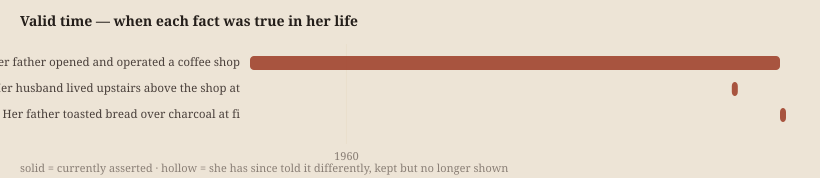

In [24]:
from IPython.display import SVG, display
from viz import bitemporal_svg

display(SVG(bitemporal_svg(her_facts)))

In [25]:
from sampan.facts import Predicate

print("The relations a fact may use, and nothing else:")
print("  " + ", ".join(p.value for p in Predicate))

The relations a fact may use, and nothing else:
  lived_at, worked_at, owned, made, ate, married_to, parent_of, sibling_of, neighbour_of, estranged_from, born_at, died, travelled_to


### Every fact has to quote her

The quote is checked against the transcript. Here is why that check exists —
the same extraction, with one fact's quote replaced by something that merely
*sounds* like evidence:

In [26]:
real = first_proposed[0]

# A fact that sounds reasonable, with a "quote" that is the model describing its
# own reasoning rather than anything she said.
invented = real.model_copy(
    update={
        "statement": "she was close to her sister",
        "quote": "The subject is identified as having a close sibling bond.",
    }
)

kept = build_facts(
    [real, invented],
    transcript=first_text,
    known_entities=outcome.entities,
    episode_id="conv_check",
)
print(f"2 facts offered, {len(kept)} accepted")
print()
print("accepted:", kept[0].statement)
print("          its quote is in the transcript:", kept[0].quote[:58])
print()
print("rejected:", invented.statement)
print("          its quote is nowhere in it:    ", invented.quote)

2 facts offered, 1 accepted

accepted: Her mother cooked salted fish fried rice a few times a week.
          its quote is in the transcript: My mother cook salted fish fried rice, few times a week.

rejected: she was close to her sister
          its quote is nowhere in it:     The subject is identified as having a close sibling bond.


The rejected one reads like a citation and is the model describing its own
reasoning. This is the fourth time that has happened in this project: it happened
with sensory details, with a safety tool that reported telling the family and
told nobody, and with map pins justified by *"Identified as being in the vicinity
of Sungai Siput"*.

The fix is always the same and always cheap. **A claim about a source can be
checked against the source.**

## 10. Looking something up mid-conversation

Now the agent can search what she has told it.

Zep searches on every turn: find the relevant facts, and paste them into that
turn's prompt. **The Live API cannot do that**, for the reason section 4 gave —
the instruction is fixed the moment the call connects. So searching has to be
started by the *agent*, through the `remember` tool, whenever the conversation
needs it.

The ranking underneath is a plain function with no model call in it. That matters
here more than elsewhere: if it returns the wrong facts, nothing crashes and no
test fails — the agent simply says something confident and wrong to her.

In [27]:
from sampan.retrieval import FactGraph, search_facts

graph = FactGraph(facts=repo.load_facts(NARRATOR), entities=outcome.entities)

print("she mentions her father's coffee shop:")

# Her father's shop is the centre of her archive, so it survives the
# run-to-run variation the previous section described.
for fact in search_facts("coffee shop", graph, limit=3):
    print("   ", fact.statement)

she mentions her father's coffee shop:
    Her mother cooked at the back of the coffee shop.
    Her father opened and operated a coffee shop at Jalan Bandar in Ipoh.
    Her father prepared charcoal-toasted bread spread with butter at the coffee shop.


### What the words miss, the graph finds

The search does not only match words. It also walks outward from whatever she is
already talking about.

Below, the same question is asked twice. First cold, with nothing else in mind.
Then again as though she had just been talking about her father's shop — which is
what happens in a real call, because the tool seeds the search with everyone
mentioned so far.

Watch the second list. The extra facts do not contain the word that was searched
for at all. They were reached by walking from the shop to the things attached to
it.

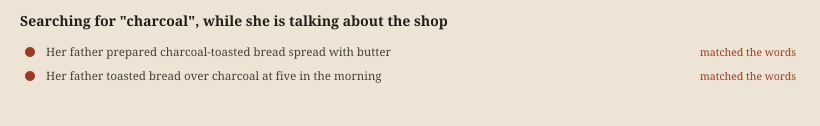

In [28]:
from viz import search_svg

# Whichever record stands for her father's shop.
shop = next(
    (
        e.entity_id
        for e in outcome.entities
        if "bandar" in e.canonical_name.lower() or "shop" in e.canonical_name.lower()
    ),
    None,
)

question = "charcoal"

cold = search_facts(question, graph, limit=4)
seeded = search_facts(question, graph, seeds=[shop] if shop else [], limit=4)

display(SVG(search_svg(question, cold, seeded)))

That is the whole idea. Word matching finds the sentence about the charcoal
fire. Walking the graph finds what else happened in the same place — who ran it,
who lived above it — none of which mentions charcoal anywhere.

**This is what makes agent-started search feel like it is paying attention.**
Nothing was injected into the prompt. The conversation's own history shaped the
answer, because the tool starts its search from the people and places she has
already brought up.

Three searches run and their results are combined:

| Search | Finds |
|---|---|
| **BM25** full-text | sentences sharing uncommon words with the question |
| **breadth-first search** | facts one or two hops from where the conversation already is |
| **cosine similarity** | *a slot, not implemented* — nothing measurable to gain at this size |

Their results are fused by **Reciprocal Rank Fusion**, which combines rank
*positions* rather than scores — a word-match score and a hop count are not
measured in the same units, and averaging them would invent a relationship
between them. Two further rerankers then apply: **node distance** from the seeds,
and **episode mentions**, which favours what she has returned to across calls.

Two of Zep's ranking steps are deliberately left out. One increases variety among
results, which matters at five hundred results and not at five. The other asks a
language model to score every candidate — the most accurate option, and an extra
model call in the middle of a live conversation while she waits.

### The bug this found within hours of being written

In [29]:
print('she asks about someone the archive has never heard of:')
print("   ", search_facts("Ah Seng", graph) or "nothing — and it says so")

she asks about someone the archive has never heard of:
    nothing — and it says so


Empty, which is correct.

It did not used to be. Asking about `Ah Seng` returned a fact about `Ah Chwee`,
because both contain `ah` — an honorific half the family shares. Word matching is
supposed to ignore words that appear everywhere, by noticing they appear
everywhere. With only a few dozen sentences in the archive, nothing appears often
enough for that to work.

Query words shorter than three characters are now ignored.

This is the worst kind of bug this product can have. Nothing throws an error. The
agent simply tells her something confident and wrong about a person she asked
after, in a voice she has come to trust.

## 11. When she remembers something differently

Everything so far assumes she tells it the same way twice. She will not.

She says the shop closed in sixty-nine. Months later she says seventy. **The shop
closed once**, so only one of those can be true — but both are things she said,
and neither can simply be deleted.

Zep's rule is to mark the older fact as no longer valid from the moment the newer
one starts. Applied here that produces: *"her father ran a coffee shop, and that
stopped being true in 1970"*. She never said that.

The problem is that two completely different situations look identical in the
data. Here is the first, using a fact she really did give:

In [30]:
from sampan.contradiction import apply_conflicting_testimony, apply_state_change
from sampan.models import Precision

# A fact with a year in it. Nobody misremembers what they had for breakfast;
# they misremember when the shop closed.
first_telling = next(
    (f for f in her_facts if f.valid_to and f.valid_to.start_year),
    her_facts[0],
)
print("what she said the first time:")
print("   ", first_telling.render())

# The same fact, told differently on a later call.
later_telling = first_telling.model_copy(
    update={
        "fact_id": "told_again",
        "statement": first_telling.statement + " (told differently later)",
        "quote": "actually I think it was a bit later than that",
    }
)

retired = apply_conflicting_testimony(first_telling, later_telling)

print()
print("SHE REMEMBERS IT DIFFERENTLY — her account changed, not the world")
print("   still what the archive shows? ", retired.is_current)
print("   still readable in the archive?", bool(retired.quote))
print("   when it was true in her life: ", "left exactly as it was")

what she said the first time:
    1958–1969 · Her father opened and operated a coffee shop at Jalan Bandar in Ipoh.

SHE REMEMBERS IT DIFFERENTLY — her account changed, not the world
   still what the archive shows?  False
   still readable in the archive? True
   when it was true in her life:  left exactly as it was


The first telling stops being shown. It is not deleted, and the years in it are
not touched — because the shop's closing did not move, only her memory of it.

Now the other situation. She lived above the shop, and years later her son moved
her to a flat. Both are true, one after the other:

In [31]:
def in_year(year):
    return When(
        raw_phrase=str(year), start_year=year,
        precision=Precision.YEAR, confidence=0.9,
    )


above_the_shop = first_telling.model_copy(
    update={"fact_id": "upstairs", "statement": "she lived above the shop",
            "valid_from": in_year(1969), "valid_to": None}
)
the_flat = first_telling.model_copy(
    update={"fact_id": "flat", "statement": "she lived in a flat in Ipoh",
            "valid_from": in_year(2016), "valid_to": None}
)

closed = apply_state_change(above_the_shop, the_flat)

print("THE WORLD CHANGED — she really did move")
print("   ", closed.render())
print("   still what the archive shows?", closed.is_current)

THE WORLD CHANGED — she really did move
    1969–2016 · she lived above the shop
   still what the archive shows? True


Here the years *are* changed: living above the shop ended when she moved into the
flat. The fact stays current, because it was true and the archive can now say for
how long.

| Situation | What changed | What the archive does |
|---|---|---|
| she moved house | the world | close the old period where the new one begins |
| *"sixty-nine"* → *"seventy"* | her account | stop showing the old telling, leave its years alone |

Business records are almost all the first kind. An oral history is almost all the
second. Sixty years on she is not reporting changes in the world; she is
recalling one fixed past with varying accuracy.

Three rules hold either way:

1. **Nothing is ever deleted.** She said it, and that stays true about her.
2. **The newest version is what gets shown** on the map and in the letters.
3. **A disagreement becomes a question, not a decision.** It reaches the next call
   the same way a missing field does, because which version is right is hers to
   settle and not the database's.

Her family can correct the *system* — the geocoder that put her village ninety
kilometres from where it is. They cannot edit what she said.

## 12. Communities — her chapters

The last layer. People, places and things that keep appearing together get
grouped, and each group is named from the facts joining them. Those groups are
the chapters of her life, and nobody writes them.

These groups are **communities**, the third tier of the graph, and the algorithm
is **label propagation**: every node starts in its own community, then repeatedly
adopts the label held by the plurality of its neighbours, until nothing moves.

Zep chooses label propagation over the better-known **Leiden** algorithm for one
reason — it extends dynamically. A single new entity can be slotted into the
community most of its neighbours are in, without recomputing anything, which is
cheap enough to run after every call. That drifts, so a full re-run is also
scheduled periodically.

In [32]:
from viz import save_graph

from sampan.communities import detect, hub_entities

name_of = {e.entity_id: e.canonical_name for e in outcome.entities}
her_graph_facts = repo.load_facts(NARRATOR)

groups = detect(outcome.entities, her_graph_facts)
print(f"communities in her archive: {len(groups)}")
for members in groups:
    print("   ", ", ".join(name_of.get(m, m) for m in members))

save_graph(
    ROOT / "notebooks" / "graph_communities.html",
    outcome.entities, her_graph_facts, groups,
    title="Her memory graph: entities joined by facts, coloured by community",
)

communities in her archive: 5
    That shop, charcoal toast, bread, Lim Ah Hock
    salted fish fried rice, Singer, Tan Ah Tai
    upstairs, Tan Eng Huat
    Penang, Lim Cheong Hin
    Ah Chwee, Sungai Siput
   graph written to graph_communities.html — 13 entities, 10 facts
   open it to explore: /Users/johnathanjohnathan/Documents/aws_ai_agent/notebooks/graph_communities.html


PosixPath('/Users/johnathanjohnathan/Documents/aws_ai_agent/notebooks/graph_communities.html')

### She breaks her own clustering

Almost every fact in her archive is about her life, so she is connected to
everyone in it. That makes her a bridge between things that have nothing else in
common, and the grouping collapses — her childhood on the estate and her years at
the shop end up in one chapter, because *she* is the only thing they share.

She belongs to every chapter of her life. That is exactly why she cannot be used
to tell them apart.

In [33]:
# Across her whole archive she is the subject of most facts -- "she lived
# above the shop", "she married Tan Eng Huat" -- so she ends up with an edge to
# nearly everyone.
#
# Whether that shows up in four sessions is luck: this run the extractor wrote
# "her father ran..." instead, so she has no node at all. Looking her up by name
# is exactly the brittle approach this section is about, so her node is built
# here and joined to everything, which is the shape the full archive has.
from sampan.models import Entity, EntityType

her = "narrator"
narrator = Entity(
    entity_id=her, type=EntityType.PERSON,
    canonical_name="Ah Khim", provisional=False,
)
everyone = [narrator, *outcome.entities]
name_of[her] = "Ah Khim"

others = sorted(
    {f.subject_id for f in her_graph_facts}
    | {f.object_id for f in her_graph_facts if f.object_id}
)
as_full_archive = her_graph_facts + [
    her_graph_facts[0].model_copy(
        update={
            "fact_id": f"hub_{i}",
            "subject_id": her,
            "object_id": other,
            "statement": f"she is connected to {name_of.get(other, other)}",
            # Emptied deliberately. These edges are constructed to show the
            # shape of the full archive, and copying the quote from the fact
            # they were cloned from would attach her sentence about her
            # mother's cooking to a claim about Penang -- exactly the thing
            # sections 9 and 10 exist to prevent.
            "quote": "",
        }
    )
    for i, other in enumerate(others)
]

collapsed = detect(everyone, as_full_archive)
print(f"with her included: {len(collapsed)} community")
save_graph(
    ROOT / "notebooks" / "graph_with_her.html",
    everyone, as_full_archive, collapsed,
    title="Everything joined to everything, through her",
)

too_connected = hub_entities(everyone, as_full_archive)
print("found by dominance, not by name:",
      [name_of.get(e, e) for e in too_connected] or "nobody")

groups = detect(everyone, as_full_archive, exclude=too_connected)
print(f"with her set aside: {len(groups)} communities")
save_graph(
    ROOT / "notebooks" / "graph_without_her.html",
    everyone, as_full_archive, groups, hub=too_connected,
    title="The same graph with her set aside: the communities separate",
)
for members in groups:
    print("   ", ", ".join(name_of.get(m, m) for m in members))

with her included: 1 community
   graph written to graph_with_her.html — 14 entities, 23 facts
   open it to explore: /Users/johnathanjohnathan/Documents/aws_ai_agent/notebooks/graph_with_her.html
found by dominance, not by name: ['Ah Khim']
with her set aside: 5 communities
   graph written to graph_without_her.html — 14 entities, 23 facts
   open it to explore: /Users/johnathanjohnathan/Documents/aws_ai_agent/notebooks/graph_without_her.html
    That shop, charcoal toast, bread, Lim Ah Hock
    salted fish fried rice, Singer, Tan Ah Tai
    upstairs, Tan Eng Huat
    Penang, Lim Cheong Hin
    Ah Chwee, Sungai Siput


Finding her took three attempts, and the first two are worth recording because
both *looked* like they worked:

- **Excluding her by name.** Her record is called `Ah Khim`; the household form
  says `Lim Siew Khim`; the profile field was empty. The exclusion list came out
  empty, the code ran, chapters appeared, and **nothing anywhere said the filter
  had matched nobody.**
- **Excluding anyone connected to more than half the graph.** Also matched
  nobody, because most of her people appear in no fact at all, so the total was
  the wrong number to measure against. Lowering it to "half" would have excluded
  the coffee shop, which is a chapter and not a bridge.
- **Excluding the clear outlier.** In the full archive she has eight connections
  and the next person has three. That is what the rule should say — and the
  script prints who it removed, because the two attempts before it were silent.

One conversation gives a small graph. Run against her whole archive, this
produces three chapters: the coffee shop years, the estate childhood, and her
grandfather's arrival from Fujian — each of which opens down to her own sentences
in the app.

## 13. Summary

| Component | Where | What it does |
|---|---|---|
| Domain model | `models.py` | Typed schema; `When`/`Where` keep her words beside the interpretation |
| Rubric | `models.assess` | Six fields, threshold four; `missing_fields` becomes the next question |
| Pre-set KB | `seeds/intake.json` | Child-completed family intake; stops painful questions |
| Call setup | `callflow.prepare_call` | Loads memory, builds the plan, closes tools over it |
| Session plan | `opener.build_session_plan` | Ranked, sensitivity-gated, depth-gated, max two offers |
| Instruction | `companion.build_instruction` | Three layers, sent **once** at connect |
| Facts | `facts.py` | Bi-temporal edges; `When` valid time, required verified quote |
| Extraction | `fact_extraction.py` | Second pass, own schema |
| Retrieval | `retrieval.search_facts` | Seam 4 — BM25 + BFS + RRF + rerankers, pure |
| Contradiction | `contradiction.py` | Routed to the right time axis; nothing deleted |
| Communities | `communities.py` | Label propagation; her chapters |
| Pull channel | `tools.remember` | One tool where there were three |
| Push channel | `tools._with_guidance` | Affect policy rides on every tool response |
| Affect | `affect.apply_assessment` | Two agreeing readings to move; distress acts immediately |
| Archivist | `archivist.ingest_conversation` | Seam 1 — text in, structured memory out |
| Persistence | `repository.py` | Entities, stories, threads, anchors, preferences, sensitivities |

### The four seams

`ingest_conversation`, `build_session_plan`, `apply_assessment` and
`search_facts` are pure functions with the model calls behind protocols. That is
why 384 tests run in under a second without touching a network.

### What I would change

Sections 9-12 did two of the three things this notebook originally listed as
future work: **join keys** are now a closed `Predicate` enum, and
**contradiction** is a modelled state rather than a last-write-wins accident.

What is still true:

1. **Persist the resolutions.** The story→entity edge is still computed every
   ingest and discarded. Facts have their own subject and object ids, so the
   graph works — but a *story* still names people as raw strings.
2. **φ_cos is a slot, not an implementation.** Retrieval is lexical and
   structural. Fine at this size, and the third leg of Zep's search is missing.
3. **Recency is not reliability.** Zep's "prioritise new information" is a
   database instinct; with a narrator of eighty the later telling may be the
   less accurate one. Followed anyway, because the alternatives need evidence we
   do not have — and `superseded_by` keeps the decision reversible.
4. **Carry affect past the hang-up.** The monitor's state is read on the
   overlay and on tool responses and is then dropped; `finish_call` could fold
   it into preferences the way the Archivist already infers them.